In [18]:
import numpy as np
import pandas as pd
import statsbomb as sb

from mplsoccer import VerticalPitch

In [19]:
events = sb.Events(event_id='3857283')

In [20]:
events = sb.Events(event_id='3857283')
df = events.get_dataframe(event_type='shot')

C:\Users\HP\anaconda3\Lib\site-packages\statsbomb\parser.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[name_cols] = df[name_cols].applymap(get_event_name)


In [26]:
print(df["period"].unique())


[1 2]


In [21]:
df = df[df["period"] != 5].copy()

In [27]:
def split_shots(df, team, period=None):
    team_df = df[df["team"] == team].copy()
    
    if period is not None:
        team_df = team_df[team_df["period"] == period]
    
    goals = team_df[team_df["outcome"] == "Goal"].copy()
    non_goals = team_df[team_df["outcome"] != "Goal"].copy()
    
    return goals, non_goals

# First half
bel_df_g_h1, bel_df_ng_h1 = split_shots(df, "Belgium", period=1)
mor_df_g_h1, mor_df_ng_h1 = split_shots(df, "Morocco", period=1)

# Second half
bel_df_g_h2, bel_df_ng_h2 = split_shots(df, "Belgium", period=2)
mor_df_g_h2, mor_df_ng_h2 = split_shots(df, "Morocco", period=2)

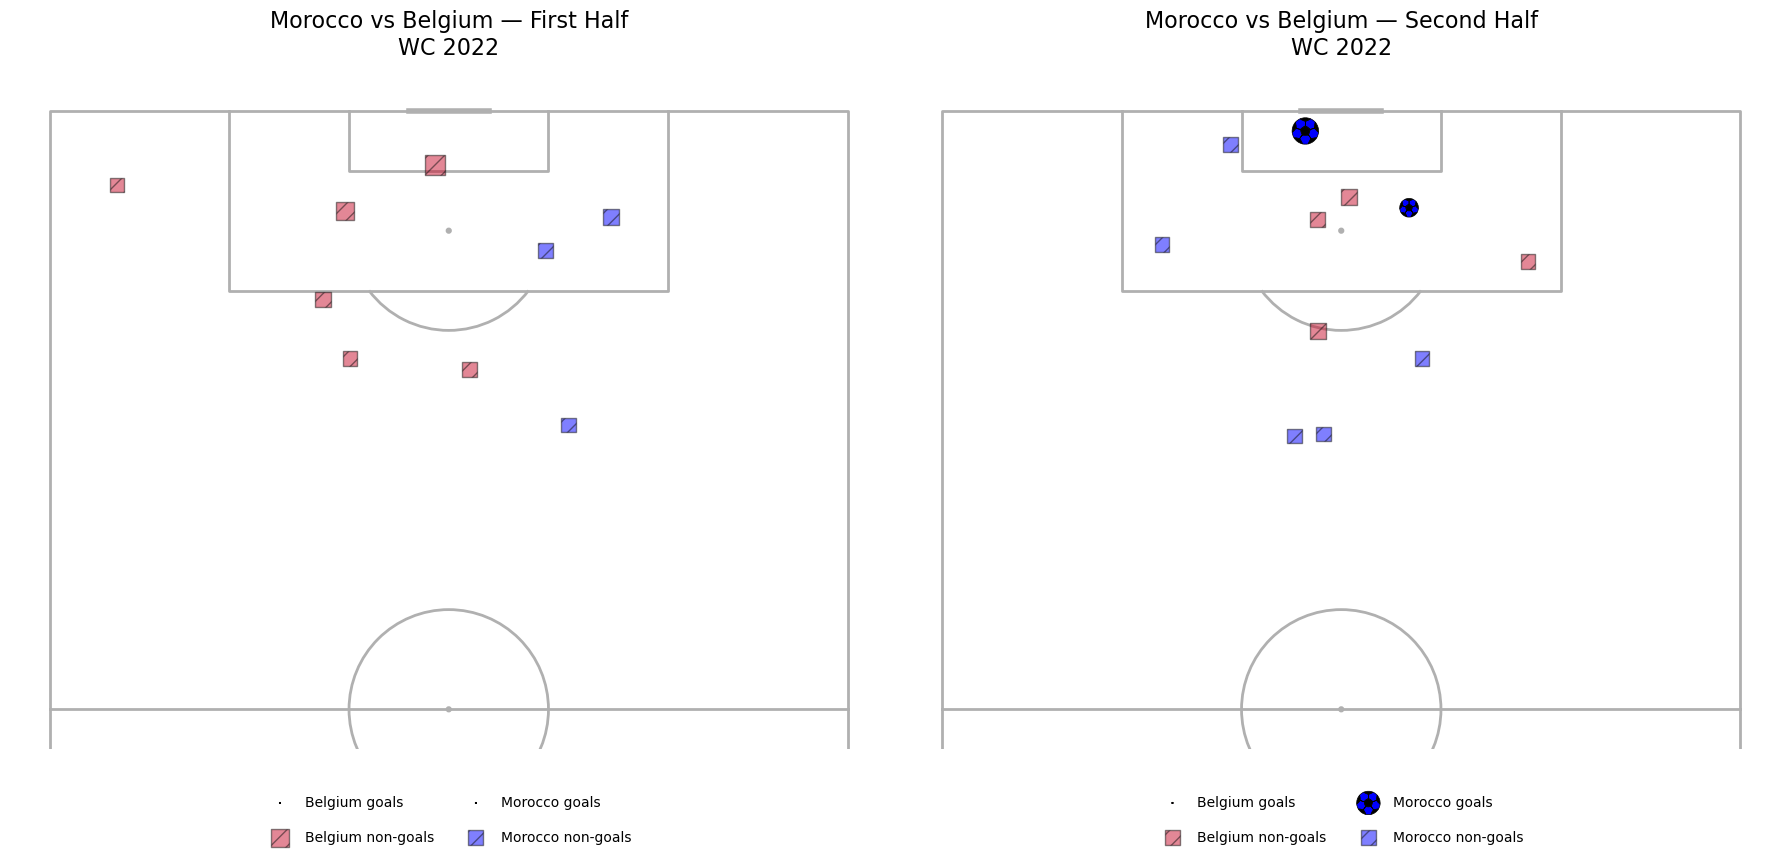

In [29]:
import matplotlib.pyplot as plt  # Import matplotlib.pyplot to fix the NameError

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
titles = ["First Half", "Second Half"]
half_data = [
    (bel_df_g_h1, bel_df_ng_h1, mor_df_g_h1, mor_df_ng_h1),
    (bel_df_g_h2, bel_df_ng_h2, mor_df_g_h2, mor_df_ng_h2),
]

pitch = VerticalPitch(half=True)

for ax, title, (bel_g, bel_ng, mor_g, mor_ng) in zip(axes, titles, half_data):
    pitch.draw(ax=ax)

    pitch.scatter(bel_g["start_location_x"], bel_g["start_location_y"],
                  s=bel_g["statsbomb_xg"]*500+100,
                  marker="football", c=bel_color, ax=ax, label="Belgium goals")

    pitch.scatter(bel_ng["start_location_x"], bel_ng["start_location_y"],
                  s=bel_ng["statsbomb_xg"]*500+100,
                  c=bel_color, alpha=0.5, hatch="//", edgecolor="#101010",
                  marker="s", ax=ax, label="Belgium non-goals")

    pitch.scatter(mor_g["start_location_x"], mor_g["start_location_y"],
                  s=mor_g["statsbomb_xg"]*500+100,
                  marker="football", c=mor_color, ax=ax, label="Morocco goals")

    pitch.scatter(mor_ng["start_location_x"], mor_ng["start_location_y"],
                  s=mor_ng["statsbomb_xg"]*500+100,
                  c=mor_color, alpha=0.5, hatch="//", edgecolor="#101010",
                  marker="s", ax=ax, label="Morocco non-goals")

    ax.set_title(f"Morocco vs Belgium — {title}\nWC 2022", size=16, pad=12)
    ax.legend(labelspacing=1.5, loc="upper center",
              bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()